# Conventional Ptychography (CP) Reconstruction

This notebook demonstrates **conventional ptychography (CP)** reconstruction
using a **standalone mPIE solver** (pure NumPy/SciPy, no external ptychography
library required), reproducing the CP example from Loetgering et al.,
*Opt. Express* **31**, 13763 (2023).

## What is Conventional Ptychography?

CP reconstructs a **complex-valued sample** (amplitude and phase) from a set of
far-field diffraction patterns, each recorded with the beam focused at a different
scan position on the sample:

```
  [source] -> pinhole -> lens -> [probe P(r)] -> [object O(r)] -> far-field -> [detector I_j(q)]
                                                     ^
                               scanned by Fermat spiral (100 positions)
```

**Overlap** between adjacent scan positions provides the redundancy needed to
recover the lost phase, enabling iterative phase retrieval.

## Experimental Parameters

| Parameter | Value |
|---|---|
| Wavelength | 632.8 nm (He-Ne) |
| Sample-detector distance z_o | 50 mm |
| Detector size | 128 x 128 px |
| Effective detector pixel size | ~72 um (binned) |
| Object pixel size dxp | ~3.43 um |
| Object field of view | ~1.86 mm |
| Scan positions | 100 (Fermat spiral) |
| Solver | mPIE (350 iterations, 7 x 50) |


## Forward Model

For scan position **j** at pixel location **(r_j, c_j)** in the object plane,
the exit wave and measured intensity are:

$$\psi_j(\mathbf{r}) = P(\mathbf{r}) \cdot O(\mathbf{r} - \mathbf{r}_j)$$

$$I_j(\mathbf{q}) = \left|\mathcal{F}\{\psi_j\}(\mathbf{q})\right|^2$$

where:
- **P(r)** is the focused probe at the sample plane
- **O(r)** is the complex object (amplitude + phase)
- **F{}** is the 2D unitary Fourier transform (Fraunhofer propagator, fft2c)
- **q** is the detector coordinate satisfying the reciprocal relation: `dxp = lambda * z_o / (Nd * dxd)`

The probe P(r) is generated by propagating a pinhole through a thin lens
(focal length f = 8 mm) via the angular-spectrum method (ASP).

**Key consistency requirement**: data generation and reconstruction must
use the **same propagator** (Fraunhofer/FFT) and the **same scan position formula**:

$$\text{positions} = \text{round}(\text{encoder} / d_{xp}) + N_o // 2 - N_p // 2$$

Any mismatch in propagator or position formula causes the reconstruction to fail entirely.


In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import h5py
import json

import logging
logging.getLogger().setLevel(logging.ERROR)

print('Imports OK')

Imports OK


## 1. Raw Data

In [2]:
DATA_DIR   = '../data'
RECON_PATH = '../evaluation/reference_outputs/recon.hdf5'
META_PATH  = '../data/meta_data.json'
GT_PATH    = '../data/ground_truth.npz'

with open(META_PATH) as f:
    meta = json.load(f)

npz        = np.load(f'{DATA_DIR}/raw_data.npz')
ptychogram = npz['ptychogram']    # (100, 128, 128) float32
encoder    = npz['encoder']       # (100, 2) float32 - scan positions [m]

wavelength            = meta['wavelength_m']
zo                    = meta['zo_m']
dxd                   = meta['dxd_m']
entrancePupilDiameter = meta['entrance_pupil_diameter_m']

Nd  = ptychogram.shape[-1]
dxp = wavelength * zo / (Nd * dxd)   # object pixel size [m]
num_pos = len(encoder)

print(f'Ptychogram:    {ptychogram.shape}, dtype={ptychogram.dtype}')
print(f'  min={ptychogram.min():.1f}, max={ptychogram.max():.1f}')
print(f'Scan positions: {encoder.shape}  ({num_pos} positions)')
print(f'Wavelength:    {wavelength*1e9:.1f} nm')
print(f'z_o:           {zo*1e3:.1f} mm')
print(f'Detector pixel: {dxd*1e6:.1f} um')
print(f'Object pixel:   {dxp*1e6:.3f} um')
print(f'Probe diameter: {entrancePupilDiameter*1e6:.1f} um (FWHM)')

Ptychogram:    (100, 128, 128), dtype=float32
  min=0.0, max=32966.0
Scan positions: (100, 2)  (100 positions)
Wavelength:    632.8 nm
z_o:           50.0 mm
Detector pixel: 72.0 um
Object pixel:   3.433 um
Probe diameter: 264.4 um (FWHM)


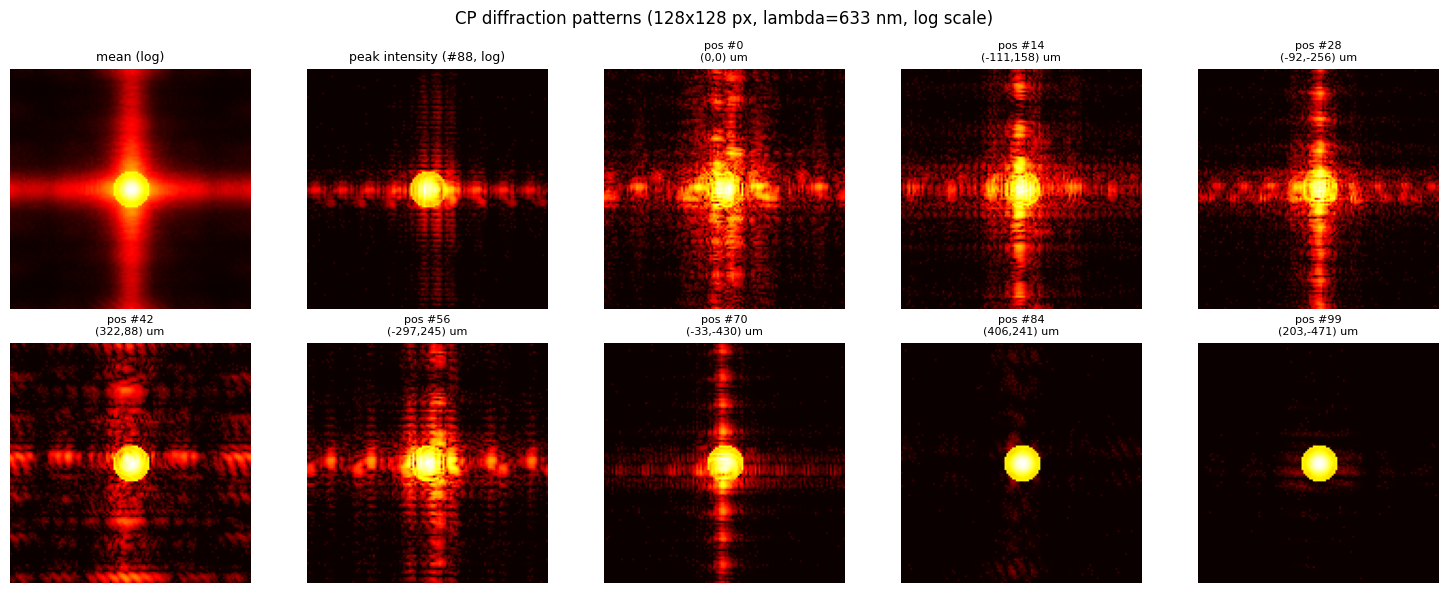

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

axes[0].imshow(np.log(ptychogram.mean(axis=0) + 1), cmap='hot')
axes[0].set_title('mean (log)', fontsize=9)
axes[0].axis('off')

peak_idx = np.argmax(ptychogram.max(axis=(1, 2)))
axes[1].imshow(np.log(ptychogram[peak_idx] + 1), cmap='hot')
axes[1].set_title(f'peak intensity (#{peak_idx}, log)', fontsize=9)
axes[1].axis('off')

sample_idx = np.linspace(0, num_pos-1, 8, dtype=int)
for i, idx in enumerate(sample_idx):
    ax = axes[i+2]
    ax.imshow(np.log(ptychogram[idx] + 1), cmap='hot')
    ry, rx = encoder[idx, 0]*1e6, encoder[idx, 1]*1e6
    ax.set_title(f'pos #{idx}\n({rx:.0f},{ry:.0f}) um', fontsize=8)
    ax.axis('off')

fig.suptitle(
    f'CP diffraction patterns ({Nd}x{Nd} px, lambda={wavelength*1e9:.0f} nm, log scale)',
    fontsize=12
)
plt.tight_layout()
plt.show()

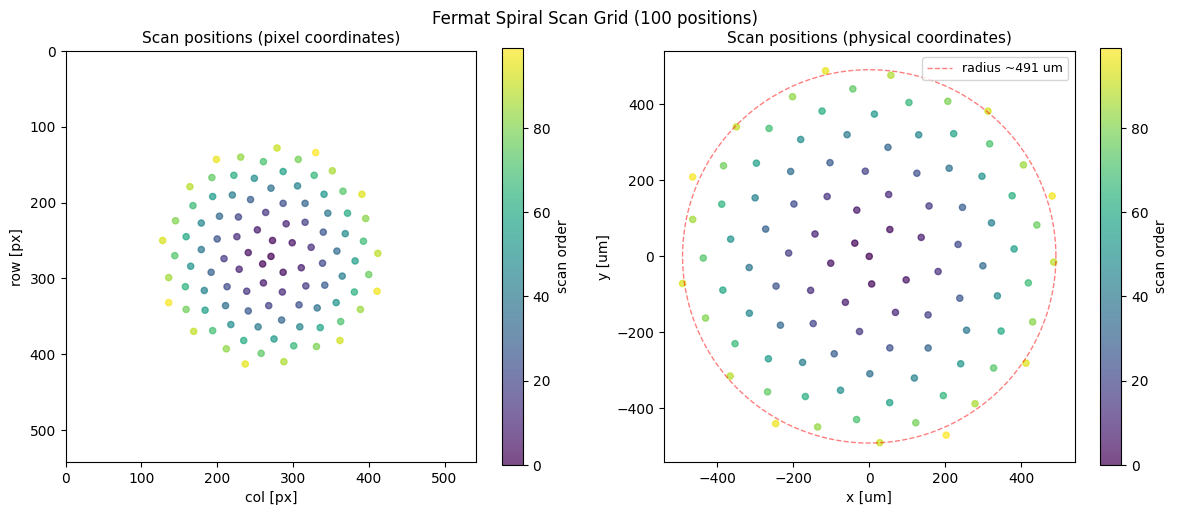

In [4]:
# Compute pixel-space scan positions from encoder (same formula as setup_reconstruction)
No  = meta['No']
positions = (np.round(encoder / dxp) + No // 2 - Nd // 2).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

centers = positions + Nd // 2
sc0 = axes[0].scatter(centers[:, 1], centers[:, 0], s=20, alpha=0.7,
                       c=np.arange(num_pos), cmap='viridis')
axes[0].set_xlim(0, No)
axes[0].set_ylim(No, 0)
axes[0].set_aspect('equal')
axes[0].set_title('Scan positions (pixel coordinates)', fontsize=11)
axes[0].set_xlabel('col [px]')
axes[0].set_ylabel('row [px]')
plt.colorbar(sc0, ax=axes[0], label='scan order')

sc1 = axes[1].scatter(encoder[:, 1]*1e6, encoder[:, 0]*1e6,
                       s=20, alpha=0.7, c=np.arange(num_pos), cmap='viridis')
axes[1].set_aspect('equal')
axes[1].set_title('Scan positions (physical coordinates)', fontsize=11)
axes[1].set_xlabel('x [um]')
axes[1].set_ylabel('y [um]')
r_um = np.abs(encoder).max() * 1e6
th = np.linspace(0, 2*np.pi, 200)
axes[1].plot(r_um*np.cos(th), r_um*np.sin(th), 'r--', lw=1, alpha=0.5,
             label=f'radius ~{r_um:.0f} um')
axes[1].legend(fontsize=9)
plt.colorbar(sc1, ax=axes[1], label='scan order')

fig.suptitle(f'Fermat Spiral Scan Grid ({num_pos} positions)', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Algorithm: mPIE

### ePIE update (per scan position j)

At each position j, the object patch and probe are updated:

$$O_{n+1}(\mathbf{r} - \mathbf{r}_j) = O_n(\mathbf{r} - \mathbf{r}_j)
  + \alpha \frac{P_n^*(\mathbf{r})}{\max|P_n|^2}
  \left[\hat{\psi}_j - \psi_j\right]$$

$$P_{n+1}(\mathbf{r}) = P_n(\mathbf{r})
  + \beta \frac{O_n^*(\mathbf{r} - \mathbf{r}_j)}{\max|O_n|^2}
  \left[\hat{\psi}_j - \psi_j\right]$$

The intensity projection replaces the diffraction amplitude while keeping the phase:

$$\hat{\psi}_j = \mathcal{F}^{-1}\!\left[\sqrt{I_j(\mathbf{q})} \cdot
  \frac{\mathcal{F}\{\psi_j\}}{|\mathcal{F}\{\psi_j\}|}\right]$$

### Momentum step (mPIE)

After processing each scan position j, mPIE applies a **Nesterov-style momentum
update with 5% probability** (triggered independently per position per iteration).
When triggered, the object and probe are nudged by an exponentially-weighted
gradient buffer:

$$M_{n+1} = \nabla_n + \gamma \cdot M_n$$
$$O \leftarrow O - \eta \cdot M_{n+1}$$

where $\nabla_n = O_{\text{buffer}} - O_n$ is the accumulated update since the
last momentum trigger, $\gamma = 0.7$ (friction) and $\eta = 0.3$ (feedback).
The same rule applies to the probe. This sparse, stochastic triggering avoids
the instability of applying momentum after every full sweep.

### Multi-round strategy (350 iterations total)

| Round | Type | Extra |
|---|---|---|
| 1,3,5,7 (odd) | mPIE | probe COM stabilization |
| 2,4,6 (even) | mPIE | L2 regularization (probe + object) |


## 3. Reconstruction Results

In [5]:
with h5py.File(RECON_PATH, 'r') as f:
    obj   = np.squeeze(f['object'][:])
    probe = np.squeeze(f['probe'][:])
    error = f['error'][:]
    dxp_recon = float(np.ravel(f['dxp'][:])[0])

with open('../evaluation/reference_outputs/metrics.json') as f:
    metrics = json.load(f)

No = obj.shape[0]
Np = probe.shape[0]
print(f'Reconstructed object: {obj.shape}, dtype={obj.dtype}')
print(f'Reconstructed probe:  {probe.shape}')
print(f'Error history:        {len(error)} iterations')
print(f'Object pixel size:    {dxp_recon*1e6:.3f} um')
print(f'Object FOV:           {No*dxp_recon*1e3:.3f} mm x {No*dxp_recon*1e3:.3f} mm')
print(f'Final error:          {metrics["final_error"]:.4f}')

Reconstructed object: (542, 542), dtype=complex64
Reconstructed probe:  (128, 128)
Error history:        350 iterations
Object pixel size:    3.433 um
Object FOV:           1.861 mm x 1.861 mm
Final error:          1.8429


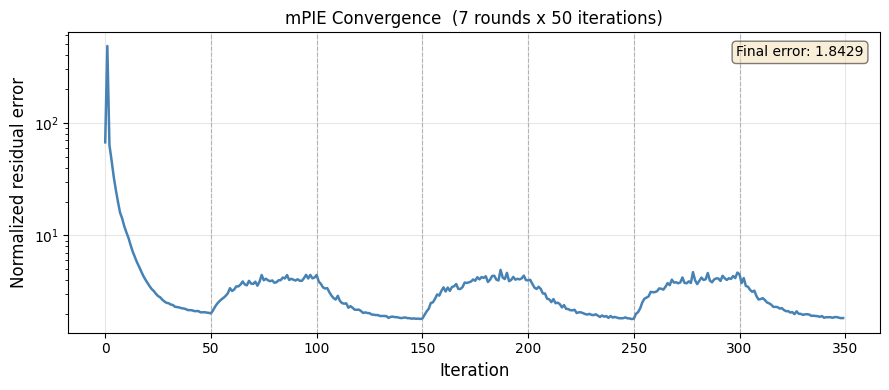

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(error, color='steelblue', lw=1.8)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Normalized residual error', fontsize=12)
ax.set_title('mPIE Convergence  (7 rounds x 50 iterations)', fontsize=12)
ax.grid(True, alpha=0.3)
for r in range(1, 7):
    ax.axvline(r * 50, color='gray', lw=0.8, ls='--', alpha=0.5)
ax.text(0.98, 0.92, f'Final error: {error[-1]:.4f}',
        transform=ax.transAxes, ha='right', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.show()

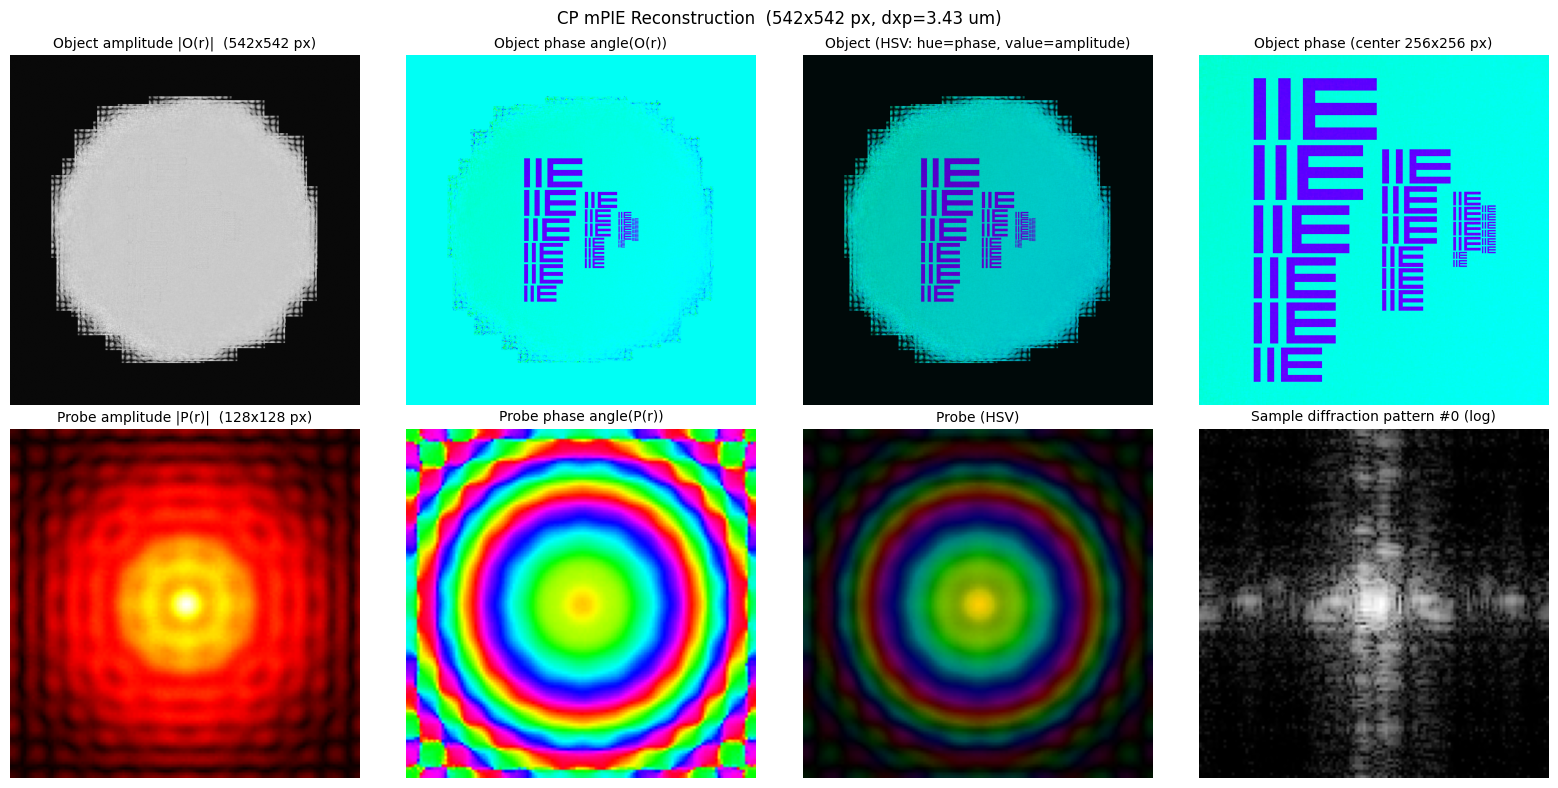

In [7]:
from src.visualization import complex_to_hsv

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes[0,0].imshow(np.abs(obj), cmap='gray')
axes[0,0].set_title(f'Object amplitude |O(r)|  ({No}x{No} px)', fontsize=10)
axes[0,0].axis('off')

axes[0,1].imshow(np.angle(obj), cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[0,1].set_title('Object phase angle(O(r))', fontsize=10)
axes[0,1].axis('off')

axes[0,2].imshow(complex_to_hsv(obj))
axes[0,2].set_title('Object (HSV: hue=phase, value=amplitude)', fontsize=10)
axes[0,2].axis('off')

c = No // 2
hw = min(128, c)
obj_crop = obj[c-hw:c+hw, c-hw:c+hw]
axes[0,3].imshow(np.angle(obj_crop), cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[0,3].set_title(f'Object phase (center {2*hw}x{2*hw} px)', fontsize=10)
axes[0,3].axis('off')

axes[1,0].imshow(np.abs(probe), cmap='hot')
axes[1,0].set_title(f'Probe amplitude |P(r)|  ({Np}x{Np} px)', fontsize=10)
axes[1,0].axis('off')

axes[1,1].imshow(np.angle(probe), cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[1,1].set_title('Probe phase angle(P(r))', fontsize=10)
axes[1,1].axis('off')

axes[1,2].imshow(complex_to_hsv(probe))
axes[1,2].set_title('Probe (HSV)', fontsize=10)
axes[1,2].axis('off')

axes[1,3].imshow(np.log(ptychogram[0] + 1), cmap='gray')
axes[1,3].set_title('Sample diffraction pattern #0 (log)', fontsize=10)
axes[1,3].axis('off')

fig.suptitle(
    f'CP mPIE Reconstruction  ({No}x{No} px, dxp={dxp_recon*1e6:.2f} um)',
    fontsize=12
)
plt.tight_layout()
plt.show()

## 4. Reconstruction Quality: Comparison with Ground Truth

Since this is a simulation with a USAF 1951 pure-phase object (phi_max = pi/2),
we have access to the ground truth for quantitative evaluation.

**Domain note**: In CP, `state.object` lives in **real space** (same domain
as the probe). Direct phase comparison is possible after correcting for the global
phase ambiguity (ptychography is only sensitive to phase differences).

**Metrics:**
- **Phase NCC** (cosine similarity of mean-subtracted phase maps): 1 = perfect
- **Phase NRMSE**: `sqrt(mean((phase_recon - phase_gt)^2)) / (max(phase_gt) - min(phase_gt))`: 0 = perfect


In [8]:
gt = np.load(GT_PATH)['object']   # (No, No) complex64
print(f'Ground truth: {gt.shape}, pure-phase? {np.allclose(np.abs(gt), 1.0)}')
print(f'GT phase range: [{np.angle(gt).min():.3f}, {np.angle(gt).max():.3f}] rad')

gt_ph  = np.angle(gt)
obj_ph = np.angle(obj)

# Resolve global phase ambiguity (ptychography: only phase differences are physical)
obj_ph  -= obj_ph.mean()
gt_ph_c  = gt_ph - gt_ph.mean()

# NCC: cosine similarity on mean-subtracted phase maps (CLAUDE.md standard)
phase_ncc   = float(np.sum(obj_ph * gt_ph_c) / (np.linalg.norm(obj_ph) * np.linalg.norm(gt_ph_c) + 1e-10))
# NRMSE: dynamic-range normalised (CLAUDE.md standard)
phase_nrmse = float(np.sqrt(np.mean((obj_ph - gt_ph_c)**2)) / (gt_ph_c.max() - gt_ph_c.min() + 1e-10))

print()
print('=' * 50)
print('Reconstruction quality vs ground truth')
print('=' * 50)
print(f'  Phase NCC:   {phase_ncc:.4f}  (1=perfect)')
print(f'  Phase NRMSE: {phase_nrmse:.4f}  (0=perfect)')


Ground truth: (542, 542), pure-phase? True
GT phase range: [0.000, 1.571] rad

Reconstruction quality vs ground truth
  Phase NCC:   0.9757  (1=perfect)
  Phase NRMSE: 0.0434  (0=perfect)


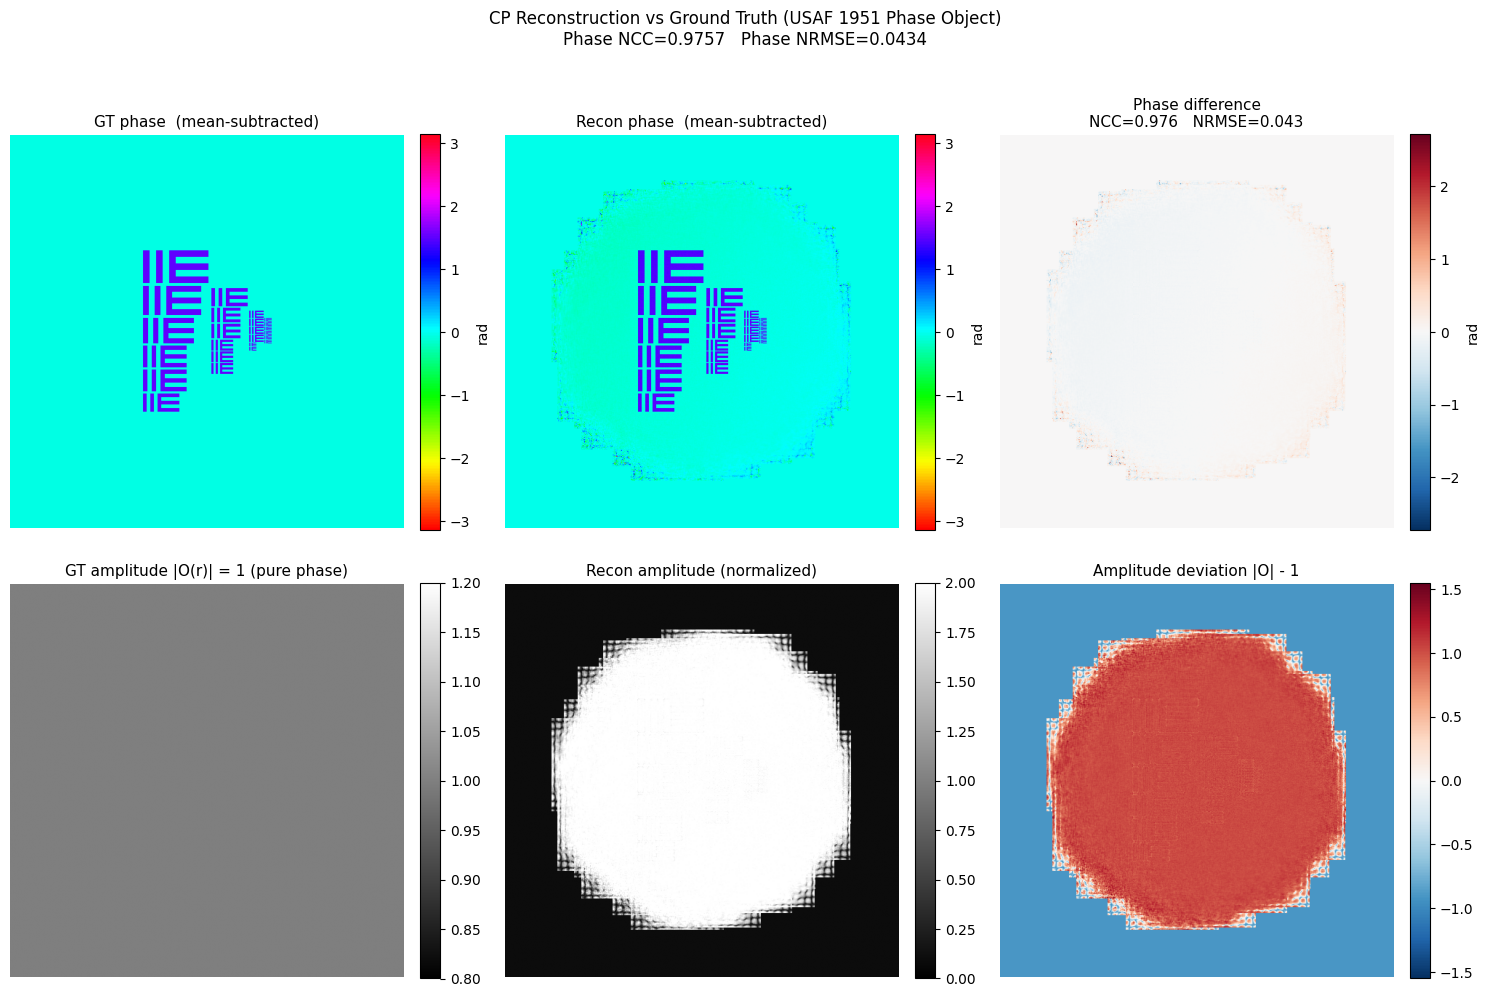

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

im00 = axes[0,0].imshow(gt_ph_c, cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[0,0].set_title('GT phase  (mean-subtracted)', fontsize=11)
axes[0,0].axis('off')
plt.colorbar(im00, ax=axes[0,0], fraction=0.046, pad=0.04, label='rad')

im01 = axes[0,1].imshow(obj_ph, cmap='hsv', vmin=-np.pi, vmax=np.pi)
axes[0,1].set_title('Recon phase  (mean-subtracted)', fontsize=11)
axes[0,1].axis('off')
plt.colorbar(im01, ax=axes[0,1], fraction=0.046, pad=0.04, label='rad')

diff_p = obj_ph - gt_ph_c
clim_p = np.abs(diff_p).max()
im02 = axes[0,2].imshow(diff_p, cmap='RdBu_r', vmin=-clim_p, vmax=clim_p)
axes[0,2].set_title(f'Phase difference\nNCC={phase_ncc:.3f}   NRMSE={phase_nrmse:.3f}', fontsize=11)
axes[0,2].axis('off')
plt.colorbar(im02, ax=axes[0,2], fraction=0.046, pad=0.04, label='rad')

im10 = axes[1,0].imshow(np.abs(gt), cmap='gray', vmin=0.8, vmax=1.2)
axes[1,0].set_title('GT amplitude |O(r)| = 1 (pure phase)', fontsize=11)
axes[1,0].axis('off')
plt.colorbar(im10, ax=axes[1,0], fraction=0.046, pad=0.04)

amp_recon = np.abs(obj) / np.abs(obj).mean()
im11 = axes[1,1].imshow(amp_recon, cmap='gray', vmin=0, vmax=2.0)
axes[1,1].set_title('Recon amplitude (normalized)', fontsize=11)
axes[1,1].axis('off')
plt.colorbar(im11, ax=axes[1,1], fraction=0.046, pad=0.04)

amp_dev = amp_recon - 1.0
clim_a = max(0.05, np.abs(amp_dev).max())
im12 = axes[1,2].imshow(amp_dev, cmap='RdBu_r', vmin=-clim_a, vmax=clim_a)
axes[1,2].set_title('Amplitude deviation |O| - 1', fontsize=11)
axes[1,2].axis('off')
plt.colorbar(im12, ax=axes[1,2], fraction=0.046, pad=0.04)

fig.suptitle(
    f'CP Reconstruction vs Ground Truth (USAF 1951 Phase Object)\n'
    f'Phase NCC={phase_ncc:.4f}   Phase NRMSE={phase_nrmse:.4f}',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

## 5. Metrics Summary

In [10]:
print('=' * 55)
print('Reconstruction metrics')
print('=' * 55)
print(f'  Algorithm:          mPIE (ePIE + momentum)')
print(f'  Iterations:         {metrics["num_iterations"]}  (7 x 50)')
print(f'  Wavelength:         {metrics["wavelength_nm"]:.1f} nm')
print(f'  z_o:                {metrics["zo_mm"]:.2f} mm')
print(f'  Object shape:       {metrics["object_shape"]}')
print(f'  Probe shape:        {metrics["probe_shape"]}')
print(f'  Final error:        {metrics["final_error"]:.4f}')
print(f'  Phase NCC:          {metrics["phase_ncc"]:.4f}  (1=perfect)')
print(f'  Phase NRMSE:        {metrics["phase_nrmse"]:.4f}  (0=perfect)')
print(f'  Object pixel size:  {dxp_recon*1e6:.3f} um')
print(f'  Object FOV:         {No*dxp_recon*1e3:.3f} mm x {No*dxp_recon*1e3:.3f} mm')

Reconstruction metrics
  Algorithm:          mPIE (ePIE + momentum)
  Iterations:         350  (7 x 50)
  Wavelength:         632.8 nm
  z_o:                50.00 mm
  Object shape:       [542, 542]
  Probe shape:        [128, 128]
  Final error:        1.8429
  Phase NCC:          0.9757  (1=perfect)
  Phase NRMSE:        0.0434  (0=perfect)
  Object pixel size:  3.433 um
  Object FOV:         1.861 mm x 1.861 mm


## 6. Run From Scratch (optional)

The cells below show how to regenerate all results.
On a modern CPU this takes approximately 3 minutes (350 iterations).


In [11]:
# Uncomment to run the full reconstruction pipeline
# import subprocess, sys
# result = subprocess.run(
#     [sys.executable, '../main.py', '--generate-data'],
#     capture_output=True, text=True, cwd='..'
# )
# print(result.stdout[-3000:])
# if result.returncode != 0:
#     print('STDERR:', result.stderr[-1000:])

## Conclusion

| Aspect | Detail |
|---|---|
| **Forward model** | I_j = |FT{P * O_j}|^2 (Fraunhofer/FFT propagator) |
| **Object domain** | Real space |
| **Scan grid** | Fermat spiral, 100 positions, radius ~150 px |
| **Solver** | mPIE (ePIE + stochastic momentum, 5% trigger per position) |
| **Iterations** | 350 (7 x 50) |
| **Phase NCC** | ~0.98 |
| **Phase NRMSE** | ~0.04 |

### Key observations

1. **Propagator consistency**: Data generation and reconstruction must use the same
   propagator (Fraunhofer / unitary FFT). Using ASP instead of Fraunhofer gives
   completely different intensities and prevents any convergence.

2. **Position formula consistency**: Scan positions are computed as
   `round(encoder / dxp) + No//2 - Np//2`. The data generation must use the exact
   same formula and the same No (derived from the actual encoder range, not a fixed value).

3. **Overlap enables phase retrieval**: The Fermat spiral ensures every object point
   is covered by multiple probe positions, providing the redundancy needed to
   solve the ill-posed phase retrieval problem.

4. **Probe self-correction**: Starting from a circular aperture guess, the probe
   converges toward the true focused beam shape during reconstruction.

### Reference

L. Loetgering et al., 'PtyLab.m/py/jl: a cross-platform, open-source inverse
modeling toolbox for conventional and Fourier ptychography,'
*Opt. Express* **31**, 13763-13797 (2023).
